# 17 — ADR Strategy Analysis

Phân tích ADR hỗ trợ chiến lược pricing / revenue management trên `hotel_bookings_v5.csv`:

1. **Seasonality** — monthly trend, weekend vs weekday differential
2. **Lead-time vs ADR** — booking window ảnh hưởng giá như thế nào
3. **Room type premium** — `reserved_room_type` vs `assigned_room_type`, upsell opportunity

**Phạm vi:** booking không hủy (`is_canceled = 0`), `adr > 0`.

In [40]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "17"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
DAY_ORDER = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday",
]
WEEKEND_DAYS = {"Friday", "Saturday", "Sunday"}
LEAD_BINS = [-1, 7, 30, 90, 180, 10_000]
LEAD_LABELS = ["0-7", "8-30", "31-90", "91-180", "180+"]

print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")

ROOT: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\17


In [41]:
def fmt_int(n) -> str:
    return f"{int(round(n)):,}".replace(",", ".")


def fmt_eur(x: float, d: int = 2) -> str:
    return f"{x:,.{d}f} €".replace(",", "X").replace(".", ",").replace("X", ".")


def fmt_pct(x: float, d: int = 1) -> str:
    return f"{x * 100:.{d}f}%".replace(".", ",")


def savefig(name: str) -> Path:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def load_stay() -> pd.DataFrame:
    df = pd.read_csv(DATA_PATH)
    stay = df[(df["is_canceled"] == 0) & (df["adr"] > 0)].copy()
    stay["arrival_date_month"] = pd.Categorical(
        stay["arrival_date_month"], categories=MONTH_ORDER, ordered=True
    )
    stay["day_of_week"] = pd.Categorical(
        stay["day_of_week"], categories=DAY_ORDER, ordered=True
    )
    stay["is_weekend"] = stay["day_of_week"].isin(WEEKEND_DAYS)
    stay["total_nights"] = (
        stay["stays_in_weekend_nights"] + stay["stays_in_week_nights"]
    ).clip(lower=0)
    stay["booking_revenue"] = stay["adr"] * stay["total_nights"]
    stay["lead_bin"] = pd.cut(
        stay["lead_time"],
        bins=LEAD_BINS,
        labels=LEAD_LABELS,
    )
    stay["room_match"] = stay["reserved_room_type"] == stay["assigned_room_type"]
    return stay


stay = load_stay()
print(f"Booking phân tích: {fmt_int(len(stay))}")
print(f"Mean ADR: {fmt_eur(stay['adr'].mean())} | Median ADR: {fmt_eur(stay['adr'].median())}")
print(f"Weekend share: {fmt_pct(stay['is_weekend'].mean())}")
stay[["adr", "lead_time", "arrival_date_month", "day_of_week", "is_weekend"]].head()

Booking phân tích: 58.066
Mean ADR: 105,92 € | Median ADR: 96,60 €
Weekend share: 42,9%


,adr,lead_time,arrival_date_month,day_of_week,is_weekend
2,75.0,7,July,Wednesday,False
3,75.0,13,July,Wednesday,False
4,98.0,14,July,Wednesday,False
5,107.0,0,July,Wednesday,False
6,103.0,9,July,Wednesday,False


## 1. Seasonality ADR

Mục tiêu: nhận diện ladder giá theo tháng và chênh weekend vs weekday để hỗ trợ rate calendar.

,bookings,mean_adr,median_adr,std_adr,season_index
arrival_date_month,,,,,
January,3309,70.16,68.00,29.02,0.66
February,4310,75.59,74.80,31.50,0.71
March,5205,80.45,77.35,32.77,0.76
April,5055,102.60,98.00,40.05,0.97
May,5395,110.21,108.00,42.89,1.04
June,5018,119.72,116.00,39.24,1.13
July,6493,137.10,130.00,49.36,1.29
August,7220,151.19,140.00,58.52,1.43
September,4487,114.53,110.00,40.66,1.08


Saved: reports\figures\17\01_monthly_adr_trend.png


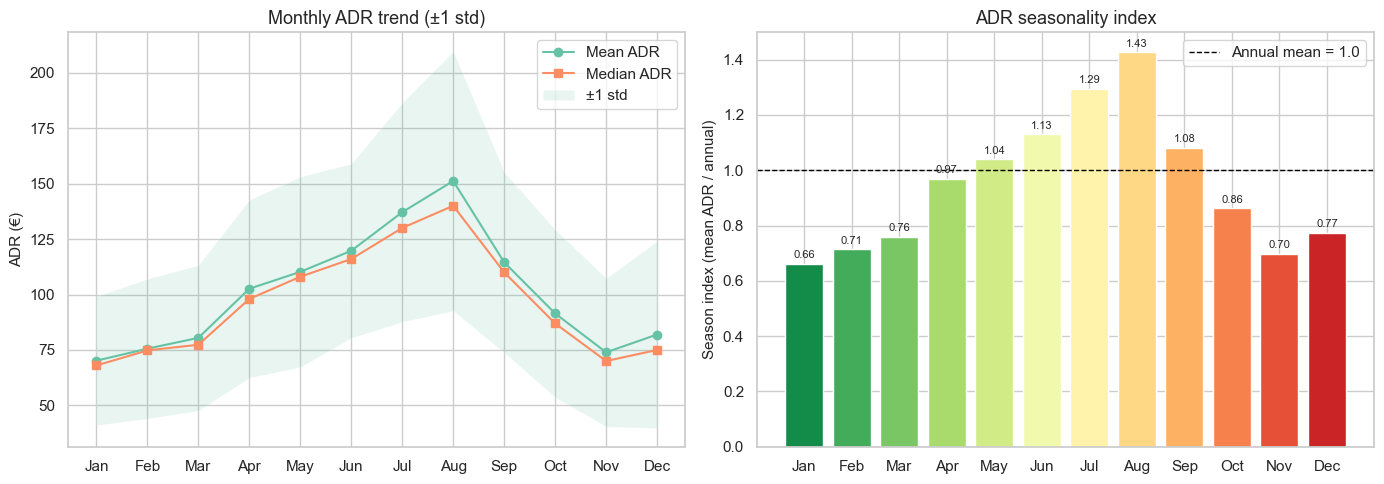

Peak: August (151,19 €) | Low: January (70,16 €) | Spread: 115,5%


In [42]:
# 1.1 Monthly trend — mean / median / volume
monthly = (
    stay.groupby("arrival_date_month", observed=True)["adr"]
    .agg(bookings="count", mean_adr="mean", median_adr="median", std_adr="std")
    .reindex(MONTH_ORDER)
)
annual_mean = stay["adr"].mean()
monthly["season_index"] = monthly["mean_adr"] / annual_mean

display(monthly.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(monthly.index.astype(str), monthly["mean_adr"], marker="o", label="Mean ADR")
ax.plot(monthly.index.astype(str), monthly["median_adr"], marker="s", label="Median ADR")
ax.fill_between(
    range(12),
    monthly["mean_adr"] - monthly["std_adr"],
    monthly["mean_adr"] + monthly["std_adr"],
    alpha=0.15,
    label="±1 std",
)
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in MONTH_ORDER], rotation=0)
ax.set_ylabel("ADR (€)")
ax.set_title("Monthly ADR trend (±1 std)")
ax.legend()

ax = axes[1]
colors = sns.color_palette("RdYlGn_r", n_colors=12)
bars = ax.bar(range(12), monthly["season_index"], color=colors)
ax.axhline(1.0, color="black", ls="--", lw=1, label="Annual mean = 1.0")
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in MONTH_ORDER])
ax.set_ylabel("Season index (mean ADR / annual)")
ax.set_title("ADR seasonality index")
ax.legend()
for i, v in enumerate(monthly["season_index"]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=8)

savefig("01_monthly_adr_trend.png")
plt.show()

peak = monthly["mean_adr"].idxmax()
low = monthly["mean_adr"].idxmin()
print(
    f"Peak: {peak} ({fmt_eur(monthly.loc[peak, 'mean_adr'])}) | "
    f"Low: {low} ({fmt_eur(monthly.loc[low, 'mean_adr'])}) | "
    f"Spread: {fmt_pct(monthly.loc[peak, 'mean_adr'] / monthly.loc[low, 'mean_adr'] - 1)}"
)

Saved: reports\figures\17\02_monthly_adr_boxplot.png


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_27688\1824943956.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m[:3] for m in MONTH_ORDER])


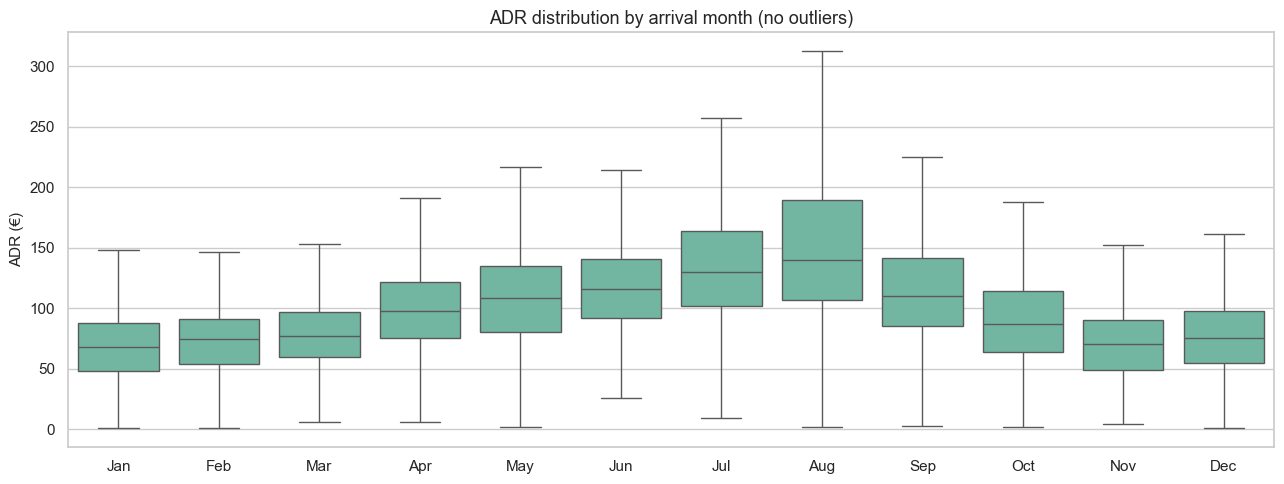

In [43]:
# 1.2 Box plot ADR theo tháng
fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(
    data=stay,
    x="arrival_date_month",
    y="adr",
    order=MONTH_ORDER,
    showfliers=False,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("ADR (€)")
ax.set_title("ADR distribution by arrival month (no outliers)")
ax.set_xticklabels([m[:3] for m in MONTH_ORDER])
savefig("02_monthly_adr_boxplot.png")
plt.show()

,bookings,mean_adr,median_adr
is_weekend,,,
Weekday (Mon–Thu),33168,104.47,95.25
Weekend (Fri–Sun),24898,107.86,98.00


Weekend − Weekday (mean): 3,39 € (3,2%)
Weekend − Weekday (median): 2,75 €
Mann–Whitney U p-value: 1.01e-17


,bookings,mean_adr,median_adr
day_of_week,,,
Monday,9586,105.86,97.00
Tuesday,7610,102.99,95.00
Wednesday,7480,102.82,94.50
Thursday,8492,105.68,96.30
Friday,8426,109.55,99.00
Saturday,8460,108.07,98.00
Sunday,8012,105.85,97.01


Saved: reports\figures\17\03_weekend_weekday_adr.png


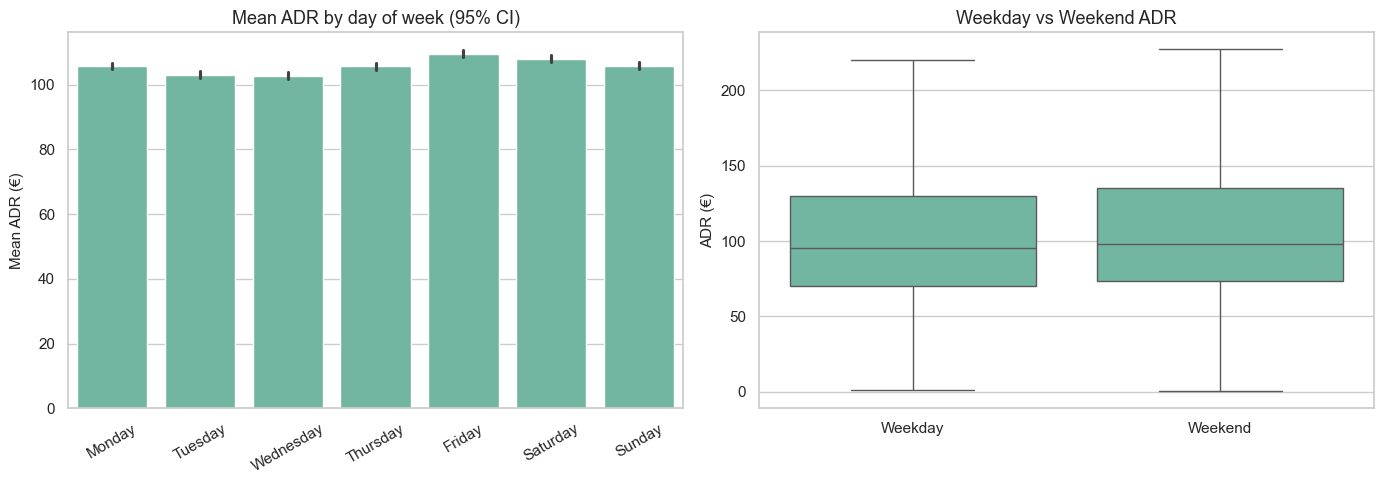

In [44]:
# 1.3 Weekend vs weekday differential
wd = stay.groupby("is_weekend", observed=True)["adr"].agg(
    bookings="count", mean_adr="mean", median_adr="median"
)
wd.index = wd.index.map({False: "Weekday (Mon–Thu)", True: "Weekend (Fri–Sun)"})
display(wd.round(2))

delta_mean = stay.loc[stay["is_weekend"], "adr"].mean() - stay.loc[~stay["is_weekend"], "adr"].mean()
delta_med = stay.loc[stay["is_weekend"], "adr"].median() - stay.loc[~stay["is_weekend"], "adr"].median()
rel = delta_mean / stay.loc[~stay["is_weekend"], "adr"].mean()
print(f"Weekend − Weekday (mean): {fmt_eur(delta_mean)} ({fmt_pct(rel)})")
print(f"Weekend − Weekday (median): {fmt_eur(delta_med)}")

# Mann-Whitney U (không giả định chuẩn)
u_stat, u_p = stats.mannwhitneyu(
    stay.loc[stay["is_weekend"], "adr"],
    stay.loc[~stay["is_weekend"], "adr"],
    alternative="two-sided",
)
print(f"Mann–Whitney U p-value: {u_p:.2e}")

dow = (
    stay.groupby("day_of_week", observed=True)["adr"]
    .agg(bookings="count", mean_adr="mean", median_adr="median")
    .reindex(DAY_ORDER)
)
display(dow.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.barplot(
    data=stay,
    x="day_of_week",
    y="adr",
    order=DAY_ORDER,
    estimator="mean",
    errorbar=("ci", 95),
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("Mean ADR (€)")
ax.set_title("Mean ADR by day of week (95% CI)")
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
sns.boxplot(
    data=stay.assign(day_type=stay["is_weekend"].map({True: "Weekend", False: "Weekday"})),
    x="day_type",
    y="adr",
    order=["Weekday", "Weekend"],
    showfliers=False,
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("ADR (€)")
ax.set_title("Weekday vs Weekend ADR")
savefig("03_weekend_weekday_adr.png")
plt.show()

,weekday_adr,weekend_adr,delta,delta_pct
arrival_date_month,,,,
January,68.53,72.32,3.79,0.06
February,74.09,77.10,3.01,0.04
March,78.54,83.40,4.87,0.06
April,101.45,103.89,2.44,0.02
May,107.25,115.16,7.91,0.07
June,118.39,121.60,3.21,0.03
July,136.16,138.19,2.03,0.01
August,149.86,153.07,3.21,0.02
September,111.82,118.39,6.57,0.06


Saved: reports\figures\17\04_seasonality_heatmap_weekend_premium.png


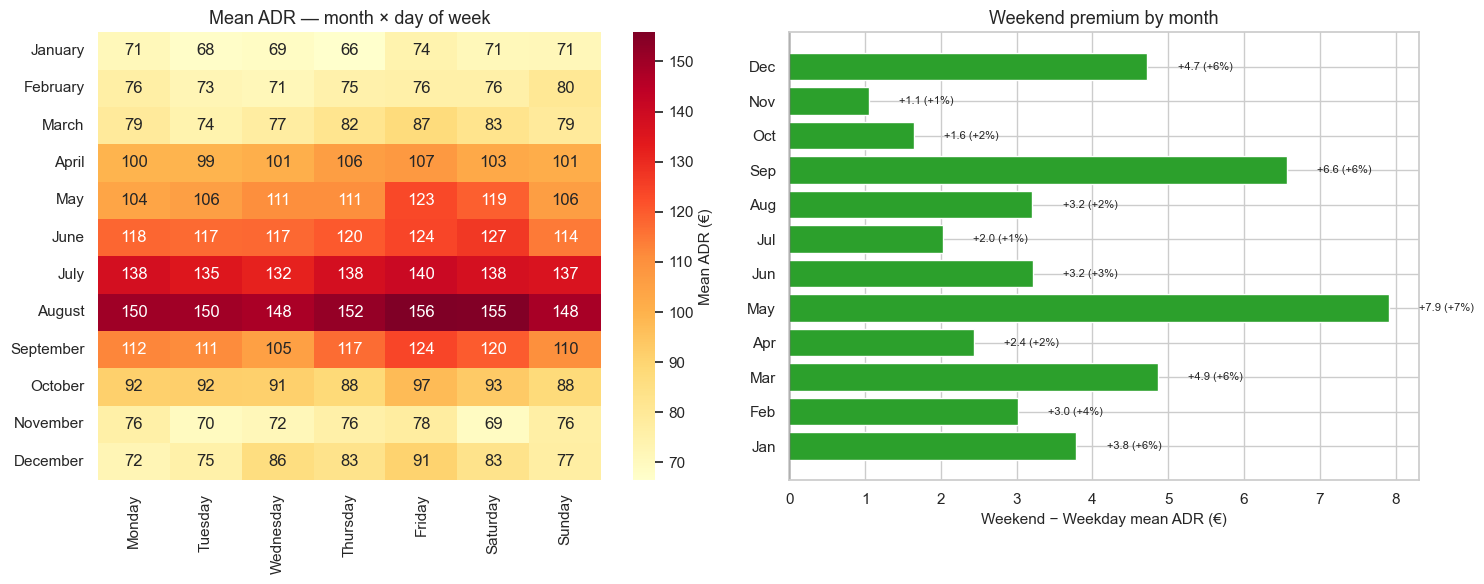

In [45]:
# 1.4 Heatmap month × weekday + weekend premium theo tháng
heat = (
    stay.pivot_table(
        index="arrival_date_month",
        columns="day_of_week",
        values="adr",
        aggfunc="mean",
        observed=True,
    )
    .reindex(index=MONTH_ORDER, columns=DAY_ORDER)
)

weekend_by_month = (
    stay.groupby(["arrival_date_month", "is_weekend"], observed=True)["adr"]
    .mean()
    .unstack("is_weekend")
    .reindex(MONTH_ORDER)
)
weekend_by_month.columns = ["weekday_adr", "weekend_adr"]
weekend_by_month["delta"] = weekend_by_month["weekend_adr"] - weekend_by_month["weekday_adr"]
weekend_by_month["delta_pct"] = weekend_by_month["delta"] / weekend_by_month["weekday_adr"]
display(weekend_by_month.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
sns.heatmap(heat, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Mean ADR (€)"})
ax.set_title("Mean ADR — month × day of week")
ax.set_xlabel("")
ax.set_ylabel("")

ax = axes[1]
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in weekend_by_month["delta"]]
ax.barh([m[:3] for m in MONTH_ORDER], weekend_by_month["delta"], color=colors)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Weekend − Weekday mean ADR (€)")
ax.set_title("Weekend premium by month")
for i, (d, p) in enumerate(zip(weekend_by_month["delta"], weekend_by_month["delta_pct"])):
    ax.text(d + (0.4 if d >= 0 else -0.4), i, f"{d:+.1f} ({p:+.0%})", va="center",
            ha="left" if d >= 0 else "right", fontsize=8)

savefig("04_seasonality_heatmap_weekend_premium.png")
plt.show()

## 2. Lead-time vs ADR

Mục tiêu: hiểu booking window ảnh hưởng price band — early-bird vs last-minute, có/không control theo mùa.

Spearman ρ (lead_time, adr): 0.090 (p=2.53e-104)
Pearson r (lead_time, adr):  0.015 (p=2.34e-04)


,bookings,mean_adr,median_adr,p25,p75
lead_bin,,,,,
0-7,14938,97.25,88.56,61.20,125.00
8-30,11456,109.94,99.00,74.00,139.00
31-90,14466,109.36,99.00,75.00,135.00
91-180,11085,111.20,104.40,79.20,134.85
180+,6121,101.87,93.73,72.76,121.50


Saved: reports\figures\17\05_lead_time_vs_adr.png


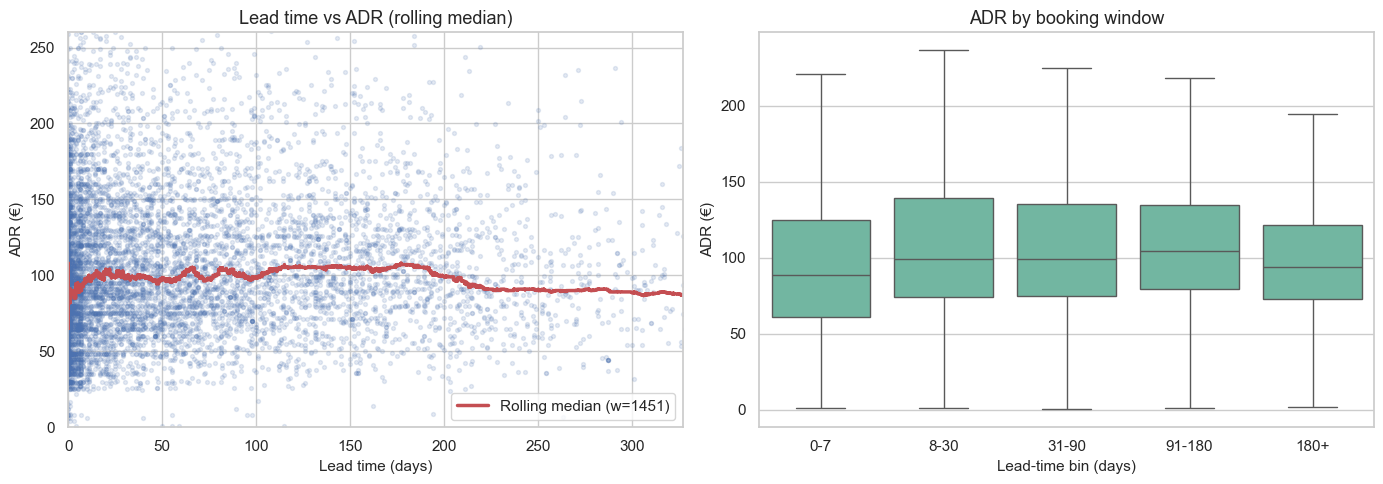

In [46]:
# 2.1 Correlation + lead bins
spearman_r, spearman_p = stats.spearmanr(stay["lead_time"], stay["adr"])
pearson_r, pearson_p = stats.pearsonr(stay["lead_time"], stay["adr"])
print(f"Spearman ρ (lead_time, adr): {spearman_r:.3f} (p={spearman_p:.2e})")
print(f"Pearson r (lead_time, adr):  {pearson_r:.3f} (p={pearson_p:.2e})")

lead_summary = (
    stay.groupby("lead_bin", observed=True)["adr"]
    .agg(bookings="count", mean_adr="mean", median_adr="median", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
)
display(lead_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
# Sample for scatter readability
sample = stay.sample(n=min(8_000, len(stay)), random_state=42)
ax.scatter(sample["lead_time"], sample["adr"], alpha=0.15, s=8, color="#4C72B0")
# Rolling median by lead_time rank bins
ordered = stay.sort_values("lead_time")
# LOESS-like: rolling median on sorted lead
window = max(500, len(ordered) // 40)
roll = ordered["adr"].rolling(window=window, center=True, min_periods=100).median()
ax.plot(ordered["lead_time"], roll, color="#C44E52", lw=2.5, label=f"Rolling median (w={window})")
ax.set_xlim(0, stay["lead_time"].quantile(0.99))
ax.set_ylim(0, stay["adr"].quantile(0.99))
ax.set_xlabel("Lead time (days)")
ax.set_ylabel("ADR (€)")
ax.set_title("Lead time vs ADR (rolling median)")
ax.legend()

ax = axes[1]
sns.boxplot(
    data=stay,
    x="lead_bin",
    y="adr",
    order=LEAD_LABELS,
    showfliers=False,
    ax=ax,
)
ax.set_xlabel("Lead-time bin (days)")
ax.set_ylabel("ADR (€)")
ax.set_title("ADR by booking window")
savefig("05_lead_time_vs_adr.png")
plt.show()

season_group,Low (Jan/Feb/Nov),Peak (Jul–Aug),Shoulder
lead_bin,,,
0-7,65.00,140.00,94.41
8-30,75.40,159.00,103.73
31-90,74.80,147.09,97.71
91-180,71.00,125.00,95.00
180+,74.47,116.12,82.92


Saved: reports\figures\17\06_lead_season_control.png


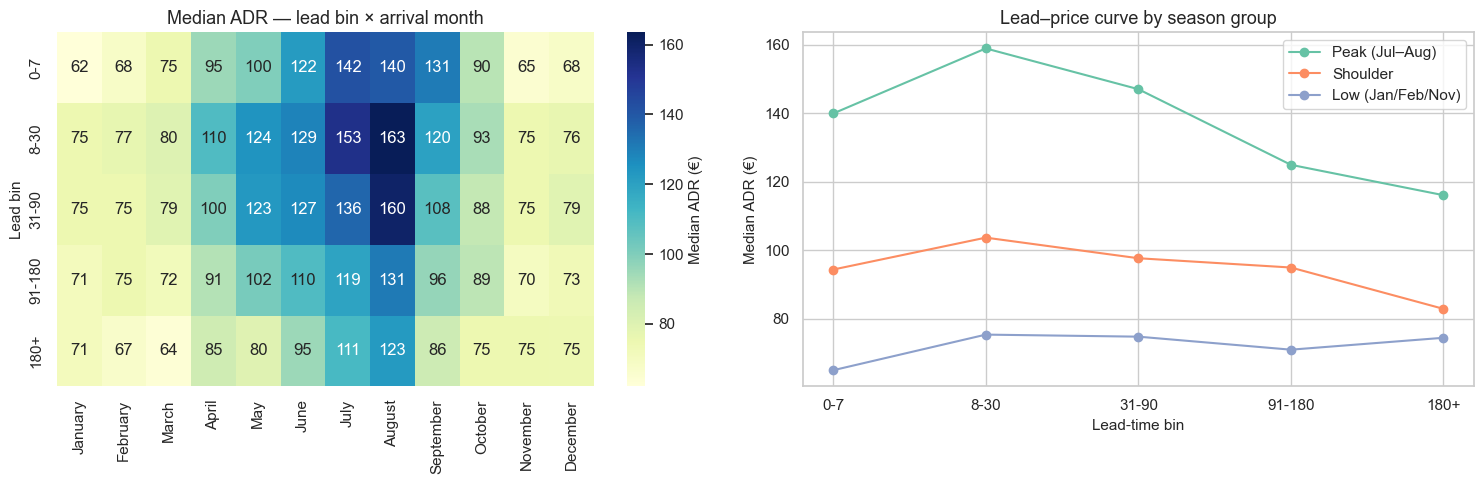

In [47]:
# 2.2 Control theo mùa: lead × month heatmap + facet by peak/off-peak
lead_month = (
    stay.pivot_table(
        index="lead_bin",
        columns="arrival_date_month",
        values="adr",
        aggfunc="median",
        observed=True,
    )
    .reindex(index=LEAD_LABELS, columns=MONTH_ORDER)
)

stay["season_group"] = np.where(
    stay["arrival_date_month"].isin(["July", "August"]),
    "Peak (Jul–Aug)",
    np.where(
        stay["arrival_date_month"].isin(["January", "February", "November"]),
        "Low (Jan/Feb/Nov)",
        "Shoulder",
    ),
)

lead_season = (
    stay.groupby(["lead_bin", "season_group"], observed=True)["adr"]
    .median()
    .unstack("season_group")
    .reindex(LEAD_LABELS)
)
display(lead_season.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
sns.heatmap(
    lead_month,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    ax=ax,
    cbar_kws={"label": "Median ADR (€)"},
)
ax.set_title("Median ADR — lead bin × arrival month")
ax.set_xlabel("")
ax.set_ylabel("Lead bin")

ax = axes[1]
for col in ["Peak (Jul–Aug)", "Shoulder", "Low (Jan/Feb/Nov)"]:
    if col in lead_season.columns:
        ax.plot(LEAD_LABELS, lead_season[col], marker="o", label=col)
ax.set_xlabel("Lead-time bin")
ax.set_ylabel("Median ADR (€)")
ax.set_title("Lead–price curve by season group")
ax.legend()
savefig("06_lead_season_control.png")
plt.show()

market_segment,Corporate,Direct,Groups,Offline TA/TO,Online TA
lead_bin,,,,,
0-7,65.00,91.00,64.50,65.00,100.04
8-30,66.18,114.68,84.75,74.68,111.00
31-90,67.00,121.72,75.00,75.00,108.23
91-180,86.00,124.62,70.00,80.75,115.00
180+,89.00,115.20,68.00,83.00,106.24


Saved: reports\figures\17\07_lead_by_segment.png


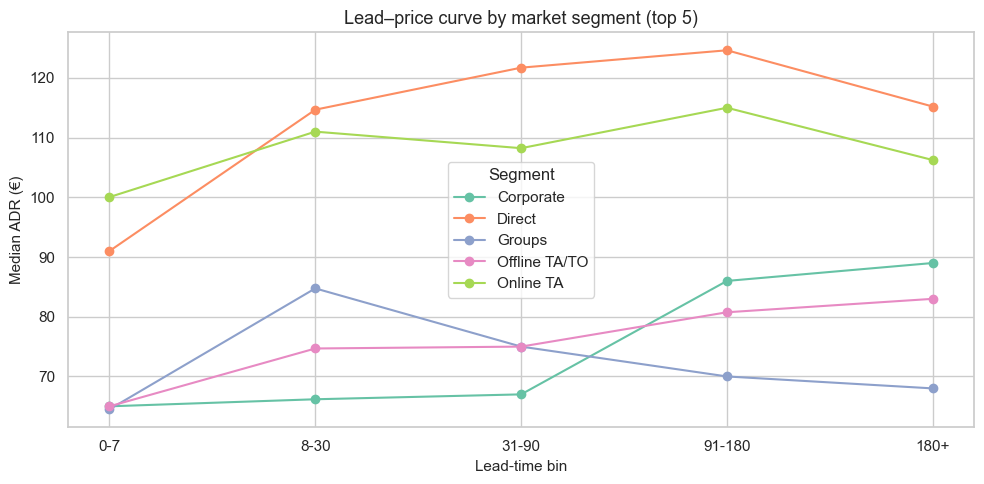

Last-minute (0-7) median: 88,56 € | Early-bird (180+) median: 93,73 € | Gap (late − early): -5,17 €


In [48]:
# 2.3 Stratify by market segment (top segments)
top_segments = stay["market_segment"].value_counts().head(5).index.tolist()
seg = stay[stay["market_segment"].isin(top_segments)].copy()

lead_seg = (
    seg.groupby(["lead_bin", "market_segment"], observed=True)["adr"]
    .median()
    .unstack("market_segment")
    .reindex(LEAD_LABELS)
)
display(lead_seg.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
for col in lead_seg.columns:
    ax.plot(LEAD_LABELS, lead_seg[col], marker="o", label=col)
ax.set_xlabel("Lead-time bin")
ax.set_ylabel("Median ADR (€)")
ax.set_title("Lead–price curve by market segment (top 5)")
ax.legend(title="Segment")
savefig("07_lead_by_segment.png")
plt.show()

# Early-bird vs last-minute summary
early = stay[stay["lead_bin"] == "180+"]["adr"]
late = stay[stay["lead_bin"] == "0-7"]["adr"]
print(
    f"Last-minute (0-7) median: {fmt_eur(late.median())} | "
    f"Early-bird (180+) median: {fmt_eur(early.median())} | "
    f"Gap (late − early): {fmt_eur(late.median() - early.median())}"
)

## 3. Room type premium & upsell opportunity

Xếp hạng phòng bằng **median ADR** của `reserved_room_type` (không dùng alphabet).  
Phân loại Same / Upgrade / Downgrade và ước lượng doanh thu bỏ lỡ từ free upgrade.

,median_adr,rank,bookings_reserved,premium_vs_prev
I,79.21,1,0,0.00
B,87.00,2,623,7.79
A,89.00,3,37566,2.00
K,99.00,4,0,10.00
E,111.58,5,4204,12.59
D,117.50,6,11614,5.91
L,150.00,7,3,32.50
C,160.00,8,591,10.00
F,171.45,9,1888,11.45
H,175.00,10,347,3.55


Saved: reports\figures\17\08_room_price_ladder.png


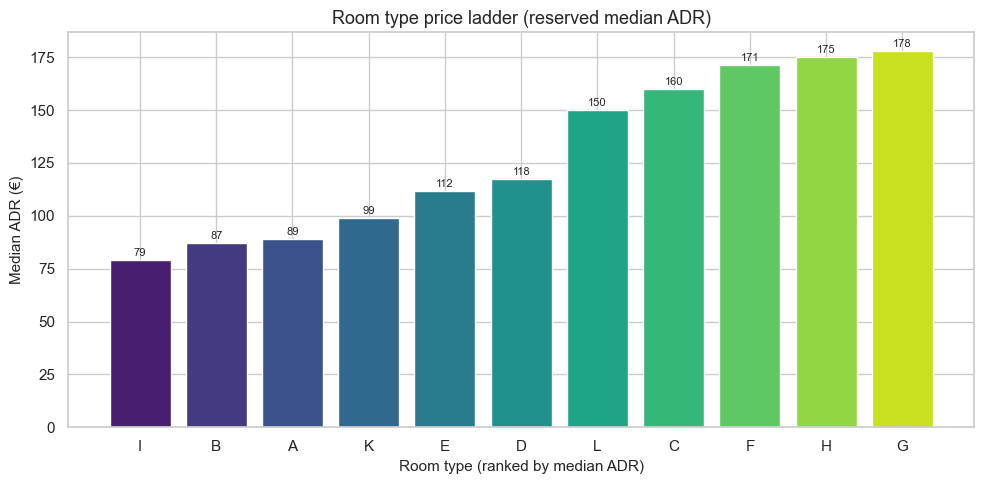

In [49]:
# 3.1 Room ladder từ median ADR
reserved_med = stay.groupby("reserved_room_type", observed=True)["adr"].median()
assigned_med = stay.groupby("assigned_room_type", observed=True)["adr"].median()
reserved_n = stay.groupby("reserved_room_type", observed=True)["adr"].count()

all_types = sorted(set(reserved_med.index) | set(assigned_med.index))
medians = {
    rt: float(reserved_med[rt]) if rt in reserved_med.index else float(assigned_med[rt])
    for rt in all_types
}
ladder = pd.Series(medians).sort_values()
rank_map = {rt: i + 1 for i, rt in enumerate(ladder.index)}

room_table = pd.DataFrame({
    "median_adr": ladder.values,
    "rank": [rank_map[rt] for rt in ladder.index],
    "bookings_reserved": [int(reserved_n.get(rt, 0)) for rt in ladder.index],
}, index=ladder.index)
room_table["premium_vs_prev"] = room_table["median_adr"].diff().fillna(0)
display(room_table.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(room_table.index.astype(str), room_table["median_adr"], color=sns.color_palette("viridis", n_colors=len(room_table)))
for i, (rt, row) in enumerate(room_table.iterrows()):
    ax.text(i, row["median_adr"] + 2, f"{row['median_adr']:.0f}", ha="center", fontsize=8)
ax.set_ylabel("Median ADR (€)")
ax.set_xlabel("Room type (ranked by median ADR)")
ax.set_title("Room type price ladder (reserved median ADR)")
savefig("08_room_price_ladder.png")
plt.show()

In [50]:
# 3.2 Mis-match taxonomy + transition matrix
mm = stay[~stay["room_match"]].copy()
mm["r_med"] = mm["reserved_room_type"].map(medians)
mm["a_med"] = mm["assigned_room_type"].map(medians)
mm["shift_type"] = np.where(mm["a_med"] > mm["r_med"], "upgrade", "downgrade")
mm["premium_gap"] = mm["a_med"] - mm["r_med"]

# Free upgrade proxy: reserved thuộc 2 mã rẻ nhất có volume reserved > 0
cheap_types = (
    room_table[room_table["bookings_reserved"] > 0]
    .nsmallest(2, "median_adr")
    .index.tolist()
)
mm["free_upgrade_proxy"] = (
    mm["reserved_room_type"].isin(cheap_types) & (mm["shift_type"] == "upgrade")
)

n_stay = len(stay)
n_mm = len(mm)
n_up = int((mm["shift_type"] == "upgrade").sum())
n_down = int((mm["shift_type"] == "downgrade").sum())
n_free = int(mm["free_upgrade_proxy"].sum())

print(f"Mis-match rate: {fmt_pct(n_mm / n_stay)} ({fmt_int(n_mm)} / {fmt_int(n_stay)})")
print(f"Upgrade: {fmt_int(n_up)} ({fmt_pct(n_up / n_mm)}) | Downgrade: {fmt_int(n_down)} ({fmt_pct(n_down / n_mm)})")
print(f"Free upgrade proxy (reserved in {cheap_types}): {fmt_int(n_free)} ({fmt_pct(n_free / n_mm)} of mis-match)")
print(f"Mean ADR match: {fmt_eur(stay.loc[stay['room_match'], 'adr'].mean())}")
print(f"Mean ADR mis-match: {fmt_eur(mm['adr'].mean())}")
print(f"ADR gap (match − mis-match): {fmt_eur(stay.loc[stay['room_match'], 'adr'].mean() - mm['adr'].mean())}")

# Opportunity: free upgrade × median premium gap (ước lượng doanh thu/đêm bỏ lỡ)
free = mm[mm["free_upgrade_proxy"]]
opp_per_night = free["premium_gap"].sum()
opp_booking = (free["premium_gap"] * free["total_nights"]).sum()
print(f"Upsell opportunity (free upgrade premium × nights): {fmt_eur(opp_booking)}")
print(f"Upsell opportunity per night sum: {fmt_eur(opp_per_night)}")

shift_summary = mm.groupby("shift_type")["adr"].agg(bookings="count", mean_adr="mean", median_adr="median")
display(shift_summary.round(2))

Mis-match rate: 18,0% (10.424 / 58.066)
Upgrade: 8.677 (83,2%) | Downgrade: 1.747 (16,8%)
Free upgrade proxy (reserved in ['B', 'A']): 7.812 (74,9% of mis-match)
Mean ADR match: 109,20 €
Mean ADR mis-match: 90,96 €
ADR gap (match − mis-match): 18,24 €
Upsell opportunity (free upgrade premium × nights): 808.631,68 €
Upsell opportunity per night sum: 284.043,89 €


,bookings,mean_adr,median_adr
shift_type,,,
downgrade,1747,112.95,108.0
upgrade,8677,86.53,75.0


,reserved_room_type,assigned_room_type,bookings,mean_premium,median_adr,nights,opp_eur
1,A,D,5324,28.50,72.00,13985,398572.50
0,A,C,980,71.00,78.99,3596,255316.00
2,A,E,802,22.59,77.60,2111,47676.94
22,E,F,346,59.86,119.25,1269,75968.68
3,A,F,285,82.45,88.00,744,61342.80
17,D,F,175,53.95,120.00,466,25140.70
4,A,G,143,88.90,95.00,284,25247.60
25,F,G,101,6.45,181.00,308,1986.60
7,B,A,97,2.00,93.82,359,718.00
6,A,K,91,10.00,95.00,320,3200.00


Saved: reports\figures\17\09_room_transition_upsell.png


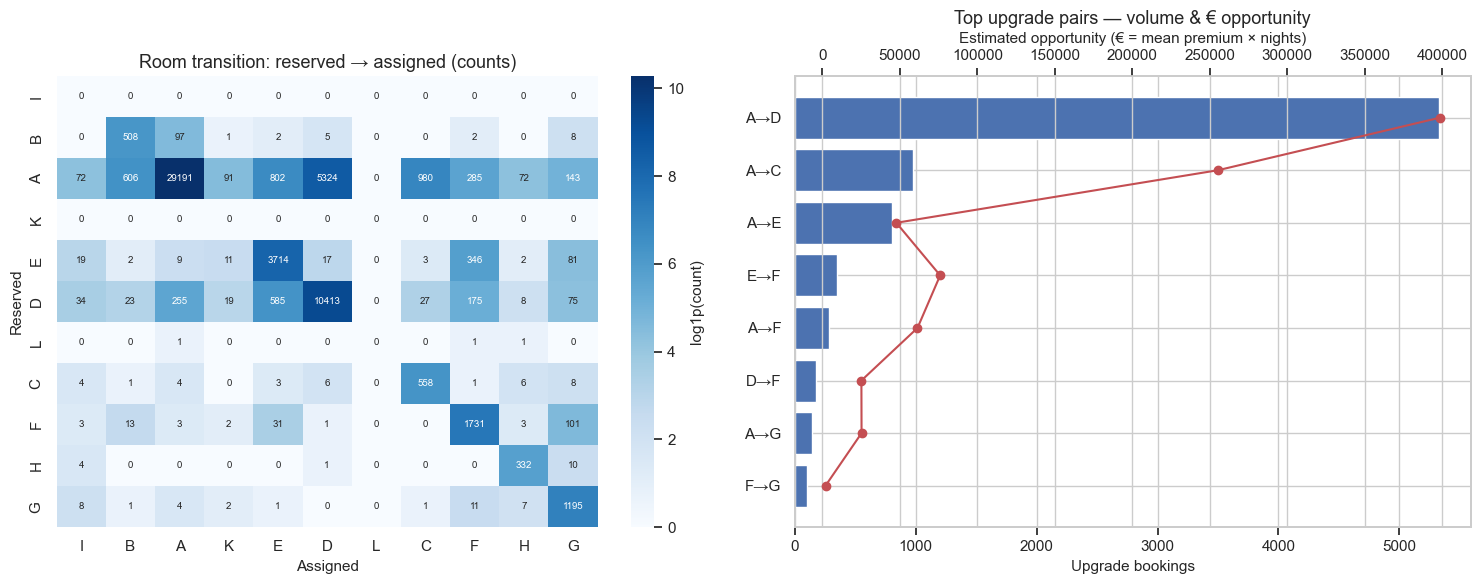

In [51]:
# 3.3 Transition heatmap + opportunity bars
trans = pd.crosstab(stay["reserved_room_type"], stay["assigned_room_type"])
# Order by ladder
type_order = list(room_table.index)
trans = trans.reindex(index=type_order, columns=type_order, fill_value=0)

# Top upgrade pairs by volume
up_pairs = (
    mm[mm["shift_type"] == "upgrade"]
    .groupby(["reserved_room_type", "assigned_room_type"], observed=True)
    .agg(
        bookings=("adr", "count"),
        mean_premium=("premium_gap", "mean"),
        median_adr=("adr", "median"),
        nights=("total_nights", "sum"),
    )
    .reset_index()
)
up_pairs["opp_eur"] = up_pairs["mean_premium"] * up_pairs["nights"]
up_pairs = up_pairs.sort_values("bookings", ascending=False)
display(up_pairs.head(10).round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
# Log1p for readability of diagonal-dominant matrix
sns.heatmap(
    np.log1p(trans),
    annot=trans.astype(int),
    fmt="d",
    cmap="Blues",
    ax=ax,
    cbar_kws={"label": "log1p(count)"},
    annot_kws={"size": 7},
)
ax.set_title("Room transition: reserved → assigned (counts)")
ax.set_xlabel("Assigned")
ax.set_ylabel("Reserved")

ax = axes[1]
top = up_pairs.head(8).copy()
top["label"] = top["reserved_room_type"].astype(str) + "→" + top["assigned_room_type"].astype(str)
ax.barh(top["label"][::-1], top["bookings"][::-1], color="#4C72B0", label="Bookings")
ax2 = ax.twiny()
ax2.plot(top["opp_eur"][::-1], top["label"][::-1], "o-", color="#C44E52", label="Opp. €")
ax.set_xlabel("Upgrade bookings")
ax2.set_xlabel("Estimated opportunity (€ = mean premium × nights)")
ax.set_title("Top upgrade pairs — volume & € opportunity")
savefig("09_room_transition_upsell.png")
plt.show()

,bookings,mean_adr,median_adr
status,,,
match,47642,109.20,99.0
upgrade,8677,86.53,75.0
downgrade,1747,112.95,108.0


Saved: reports\figures\17\10_upsell_opportunity_summary.png


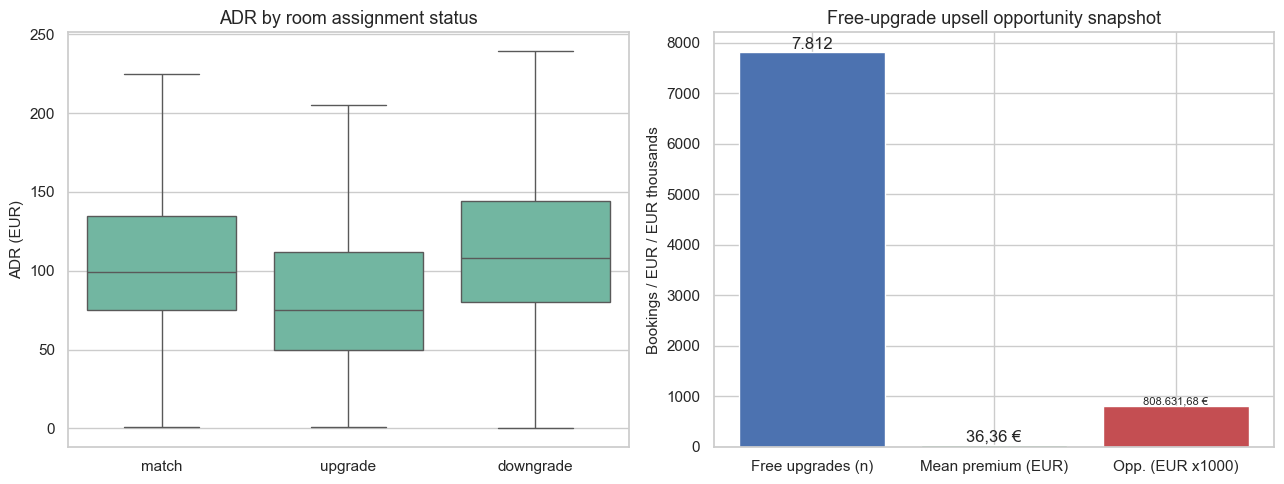

In [52]:
# 3.4 ADR comparison: match vs upgrade vs downgrade
cmp = stay.copy()
cmp["status"] = "match"
cmp.loc[mm.index, "status"] = mm["shift_type"]

status_order = ["match", "upgrade", "downgrade"]
status_adr = (
    cmp.groupby("status")["adr"]
    .agg(bookings="count", mean_adr="mean", median_adr="median")
    .reindex(status_order)
)
display(status_adr.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
sns.boxplot(data=cmp, x="status", y="adr", order=status_order, showfliers=False, ax=ax)
ax.set_title("ADR by room assignment status")
ax.set_xlabel("")
ax.set_ylabel("ADR (EUR)")

ax = axes[1]
# Opportunity snapshot (bar heights: bookings / EUR / EUR thousands)
labels = ["Free upgrades (n)", "Mean premium (EUR)", "Opp. (EUR x1000)"]
mean_prem = float(free["premium_gap"].mean()) if len(free) else 0.0
heights = [n_free, mean_prem, opp_booking / 1000]
colors = ["#4C72B0", "#55A868", "#C44E52"]
ax.bar(labels, heights, color=colors)
ax.set_ylabel("Bookings / EUR / EUR thousands")
ax.set_title("Free-upgrade upsell opportunity snapshot")
ax.text(0, heights[0], fmt_int(n_free), ha="center", va="bottom")
ax.text(1, heights[1], fmt_eur(mean_prem), ha="center", va="bottom")
ax.text(2, heights[2], fmt_eur(opp_booking), ha="center", va="bottom", fontsize=8)
savefig("10_upsell_opportunity_summary.png")
plt.show()
